In [28]:
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette
from autoslo.workload_execution.trace import Trace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [9]:
pct_heavy_options = [0, 10, 25, 50]
mean_interarrival_options = [10, 30, 60, 120]
rpus = [4, 8, 16, 32]

slo_s = 180

records = []

for pct_heavy in pct_heavy_options:
    for mean_interarrival in mean_interarrival_options:
        for rpu in rpus:
            run_id = pu.RunLocator.get_run_ids(
                workload_name="{}pctheavy_{}meaninterarrival".format(
                    pct_heavy, mean_interarrival
                ),
                blueprint_name=f"single_{rpu}",
            )[-1]

            trace = Trace(run_id)
            latencies = trace.latencies_s
            costs = trace.costs

            records.append({
                "pct_heavy": pct_heavy,
                "mean_interarrival": mean_interarrival,
                "rpu": rpu,
                "run_id": run_id,
                "slo_violation_rate": np.mean([1 if lat > slo_s else 0 for lat in latencies]), 
                "total_cost": sum(costs)
            })

records_df = pd.DataFrame(records)


In [10]:
records_df

,pct_heavy,mean_interarrival,rpu,run_id,slo_violation_rate,total_cost
0,0,10,4,1763346358,0.755224,10.007500
1,0,10,8,1765440646,0.794030,15.727500
2,0,10,16,1763304261,0.435821,11.866667
3,0,10,32,1763978737,0.038806,11.626667
4,0,30,4,1763336464,0.728070,3.867083
...,...,...,...,...,...,...
59,50,60,32,1763970399,0.000000,7.430000
60,50,120,4,1763323616,0.840000,1.916667
61,50,120,8,1765423765,0.360000,2.436667
62,50,120,16,1763291740,0.040000,3.183333


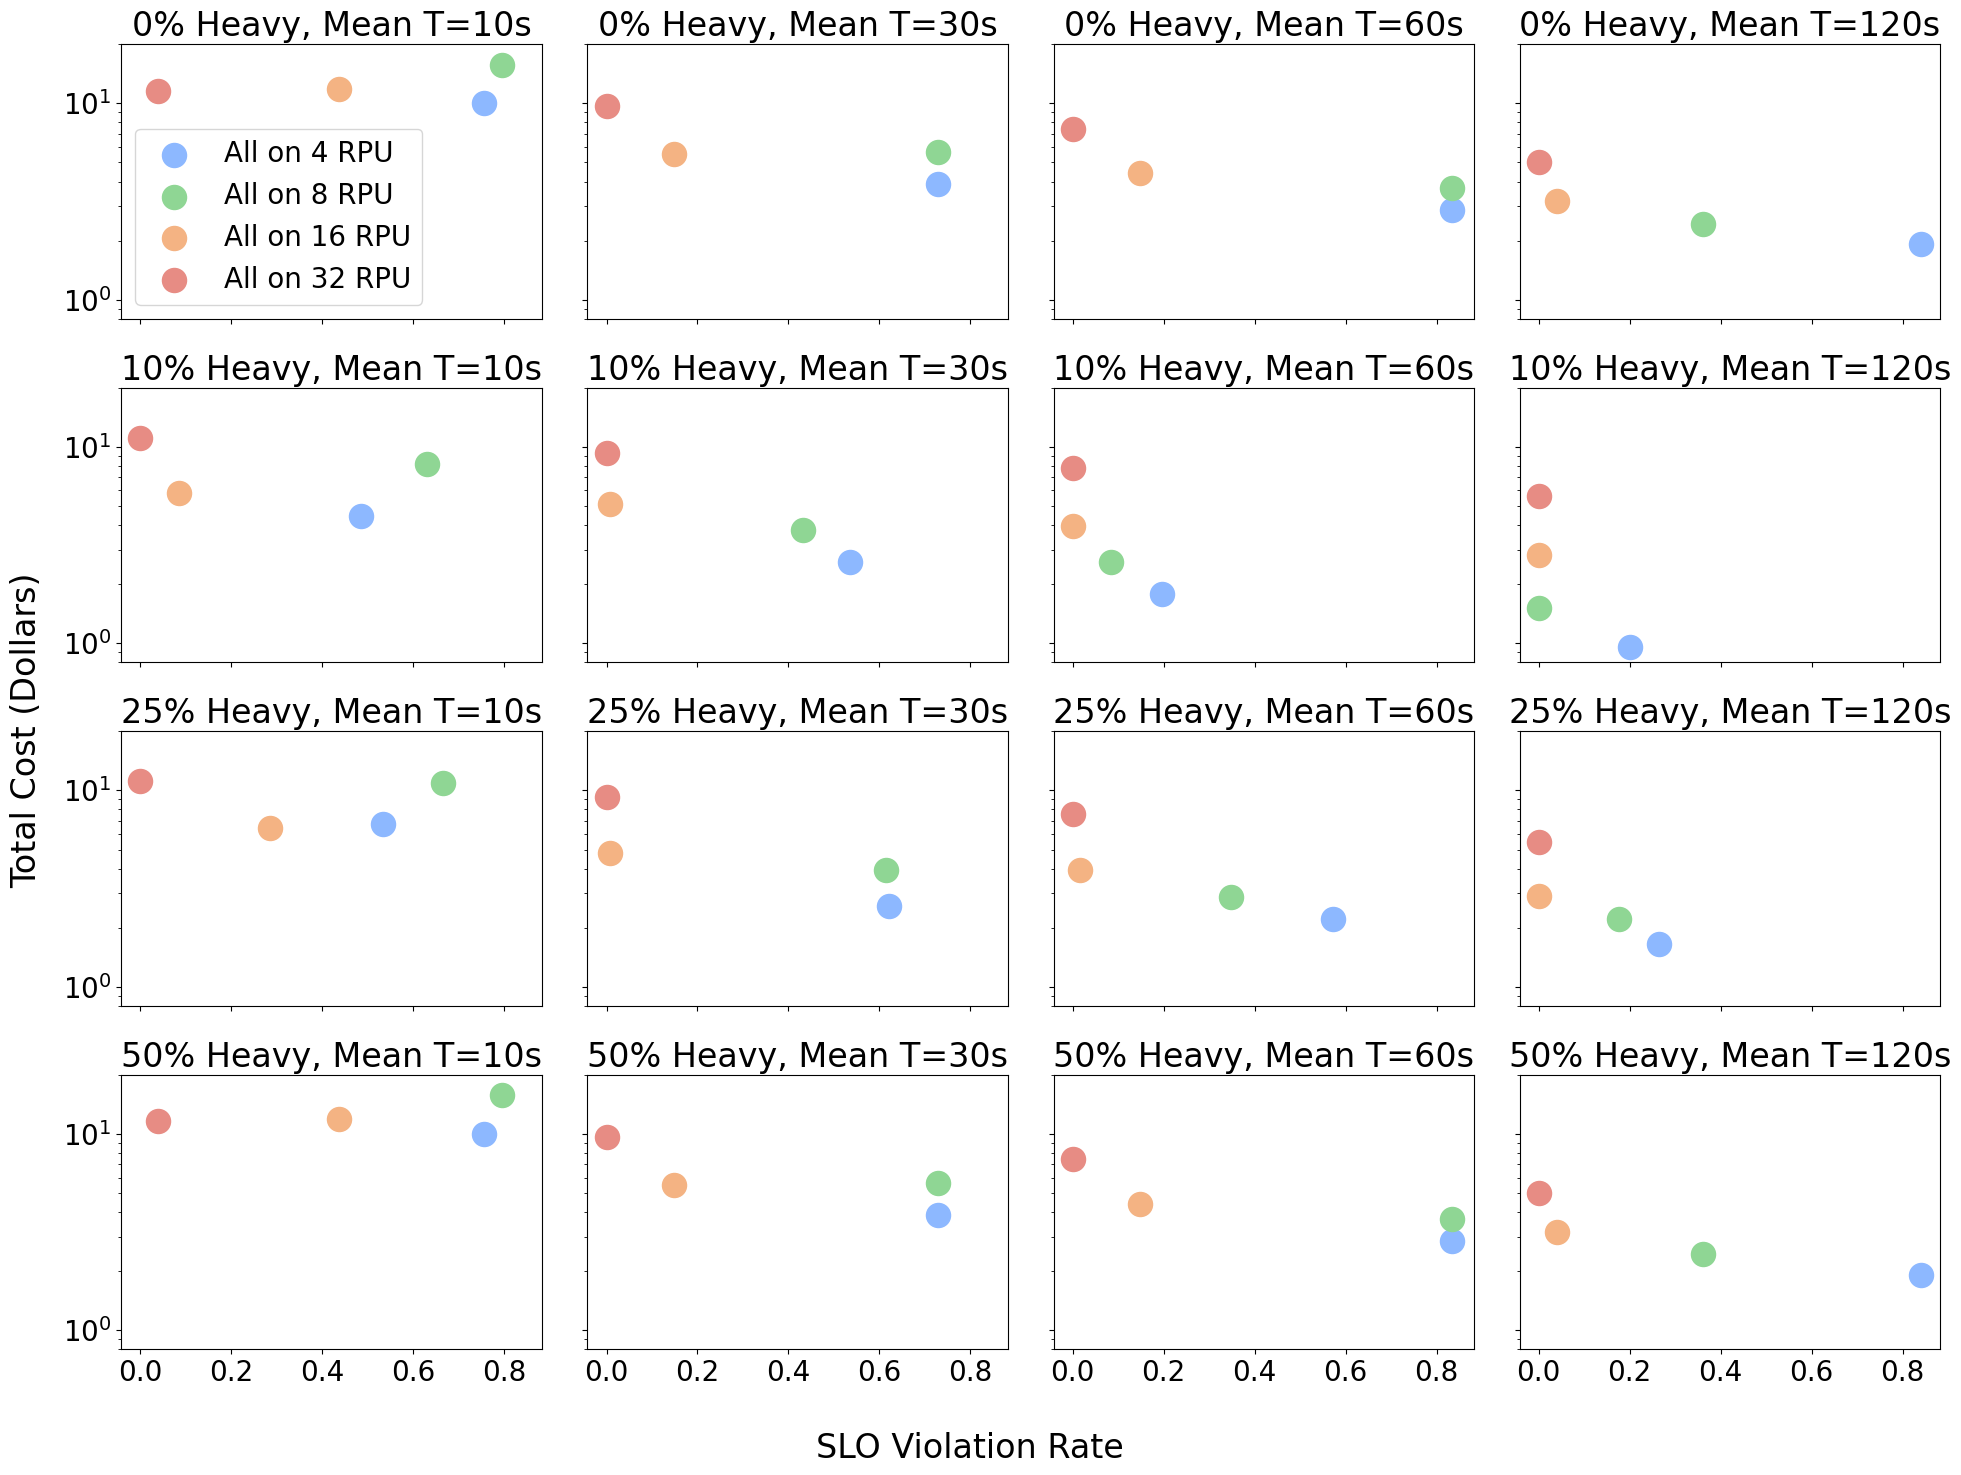

In [47]:
# Plot a 4X4 grid of chunks. In each subplot, have a scatterplot where the
# x-axis is the total cost and the y-axis is the SLO violation rate. Have each
# value of RPU be a different color.

# Make all the fonts 14 pt
plt.rcParams.update({"font.size": 20})



colors = {
    4: Palette.light_blue,
    8: Palette.light_green,
    16: Palette.light_orange,
    32: Palette.light_red,
}

def plot_one_panel(ax, pct_heavy, mean_interarrival):
    subset = records_df[
        (records_df["pct_heavy"] == pct_heavy)
        & (records_df["mean_interarrival"] == mean_interarrival)
    ]
    for rpu in rpus:
        rpu_subset = subset[subset["rpu"] == rpu]
        ax.scatter(
            rpu_subset["slo_violation_rate"],
            rpu_subset["total_cost"],
            label=f"All on {rpu} RPU",
            s=300,
            color=colors[rpu],
        )
    ax.set_title(
        f"{pct_heavy}% Heavy, Mean T={mean_interarrival}s"
    )

fig, axes = plt.subplots(4, 4, figsize=(20, 15), sharex=True, sharey=True)


for i, pct_heavy in enumerate(pct_heavy_options):
    for j, mean_interarrival in enumerate(mean_interarrival_options):
        ax = axes[i, j]
        plot_one_panel(ax, pct_heavy, mean_interarrival)
        if i == 0 and j == 0:
            ax.legend()

fig.supxlabel("SLO Violation Rate")
fig.supylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.ylim(0.8, 20)
plt.tight_layout()
plt.savefig("chunk_grid.svg")
plt.show()

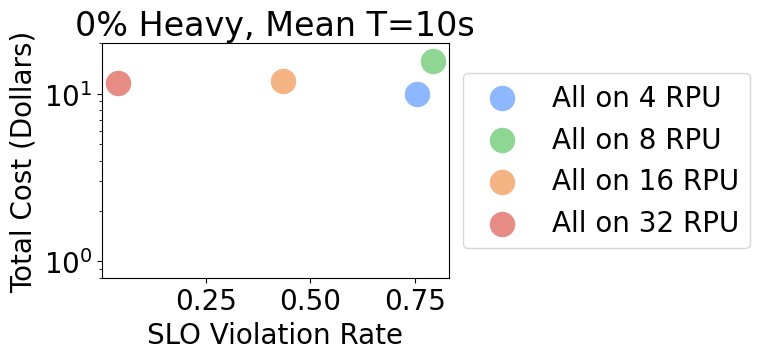

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True, sharey=True)



plot_one_panel(ax, pct_heavy_options[0], mean_interarrival_options[0])
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

ax.set_xlabel("SLO Violation Rate")
ax.set_ylabel("Total Cost (Dollars)")
plt.yscale("log")
plt.ylim(0.8, 20)
plt.tight_layout()
plt.savefig("chunk_grid_one.svg", bbox_inches="tight")
plt.show()